# Member 1 - Missing Value and Duplicate Handling

**Student ID:** IT25100065  
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
Missing value detection and handling, and duplicate record removal.

## Explanation
Missing values are incomplete observations in a dataset and may affect data
analysis and machine learning algorithms.

Duplicate records are repeated observations that may unnecessarily influence
the analysis.

## Justification
Before performing other preprocessing techniques, the dataset should be checked
for missing values and duplicate records to ensure data quality.

The assigned insurance dataset will first be examined for missing values.
Imputation will only be performed if missing values are actually present.
Duplicate records will also be identified and removed.

## EDA
A histogram of insurance charges will be used to examine the distribution of
the target variable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [4]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing Values: 0


In [5]:
if df.isnull().sum().sum() == 0:

    print("No missing values found.")
    print("Therefore, no imputation was required.")

else:

    numeric_columns = df.select_dtypes(
        include="number"
    ).columns

    categorical_columns = df.select_dtypes(
        include="object"
    ).columns

    for column in numeric_columns:
        df[column] = df[column].fillna(
            df[column].median()
        )

    for column in categorical_columns:
        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

    print("Missing values handled successfully.")

No missing values found.
Therefore, no imputation was required.


In [6]:
duplicates_before = df.duplicated().sum()

print(
    "Number of Duplicate Rows Before Cleaning:",
    duplicates_before
)

Number of Duplicate Rows Before Cleaning: 1


In [7]:
df = df.drop_duplicates().reset_index(drop=True)

duplicates_after = df.duplicated().sum()

print(
    "Duplicate Rows After Cleaning:",
    duplicates_after
)

print(
    "Dataset Shape After Cleaning:",
    df.shape
)

Duplicate Rows After Cleaning: 0
Dataset Shape After Cleaning: (1337, 7)


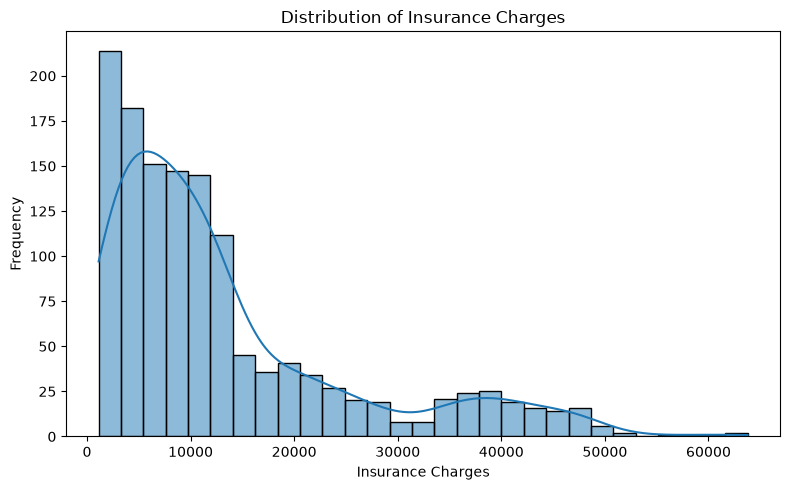

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member1_charges_distribution.png"
)

plt.show()

## EDA Interpretation

The histogram shows that insurance charges are right-skewed.

Most customers have relatively lower insurance charges, while a smaller number
of customers have very high charges.

This indicates that medical expenses vary considerably among customers and that
some observations have substantially higher costs than the majority.

In [9]:
df.to_csv(
    "../results/outputs/member1_cleaned.csv",
    index=False
)

print("Member 1 preprocessing completed.")
print("Output saved as member1_cleaned.csv")

Member 1 preprocessing completed.
Output saved as member1_cleaned.csv
